In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np

In [2]:
envs = ["atari_battle_zone", "atari_double_dunk", "atari_phoenix", "atari_this_game", "atari_battle_zone", "box2d_lunar_lander", "box2d_continuous_lunar_lander", "box2d_bipedal_walker", "cc_acrobot", "cc_cartpole", "cc_mountain_car", "cc_continuous_mountain_car", "cc_pendulum", "minigrid_door_key", "minigrid_empty_random", "minigrid_four_rooms", "minigrid_unlock", "brax_ant", "brax_halfcheetah", "brax_hopper", "brax_humanoid"]
algos = ["ppo", "dqn", "sac"]

data = []
for env in envs:
    for algo in algos:
        try:
            partial_data = pd.read_csv(f"arlbench_data/256_10/{env}_{algo}.csv")
            partial_data["env_name"] = env
            partial_data["algorithm"] = algo
            data.append(partial_data)
        except FileNotFoundError:
            continue
data = pd.concat(data)

In [3]:
## add domain
data["domain"] = data["env_name"].apply(lambda x: x.split("_")[0])

In [4]:
# normalization cross-algorithm per environment
data["normed_performance"] = data.groupby("env_name")["performance"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8)
)

# on data_two we normalize per env and algorithm
data["normed_performance_per_alg"] = data.groupby(["env_name", "algorithm"])["performance"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8)
)

# on data_two we normalize per env and algorithm
data["_seed_avg"] = data.groupby(["env_name", "algorithm", "config_id"])["performance"].transform("mean")
data["normed_performance_per_alg_seedavg"] = data.groupby(["env_name", "algorithm"], group_keys=False).apply(
    lambda g: (g["performance"] - g["_seed_avg"].min()) / (g["_seed_avg"].max() - g["_seed_avg"].min() + 1e-8)
)
data.drop(columns=["_seed_avg"], inplace=True)

/var/folders/5n/lj6nx7xj3mx2yb3sk947mnlc0000gn/T/ipykernel_84473/355322313.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data["normed_performance_per_alg_seedavg"] = data.groupby(["env_name", "algorithm"], group_keys=False).apply(


In [5]:
# remove trash environments because they kill the cross-environment ranking later
bad_envs = ["cc_mountain_car", "minigrid_unlock"]
data = data[~data["env_name"].isin(bad_envs)]

In [6]:
def compute_rankings_counting(mu: np.ndarray, sigma: np.ndarray) -> np.ndarray:
    """
    Compute rankings based on counting overlaps, without sorting or binary search.
    
    For each configuration j, we count:
    - How many configurations have upper bound (μ + σ) below j's lower bound (μ - σ)
      → these are strictly worse (gives lower bound on rank)
    - How many configurations have lower bound (μ - σ) below j's upper bound (μ + σ)
      → these overlap or are worse (gives upper bound on rank)
    
    The rank is the average of these bounds.
    
    Args:
        mu: Array of shape (n,) with aggregate metrics for each configuration
        sigma: Array of shape (n,) with spread metrics for each configuration
    
    Returns:
        ranks: Array of shape (n,) with the computed rank for each configuration
    """
    n = len(mu)
    
    # Compute bounds for all configurations
    upper_bounds = mu + sigma  # Best case for each config
    lower_bounds = mu - sigma  # Worst case for each config
    
    # For each configuration j, compute rank bounds
    l = np.zeros(n)  # Lower rank bound (1-indexed rank)
    u = np.zeros(n)  # Upper rank bound (1-indexed rank)
    
    for j in range(n):
        # Count how many configurations are strictly better than j
        # (their lower bound is above j's upper bound)
        strictly_better = np.sum(lower_bounds > upper_bounds[j])
        
        # Count how many configurations could potentially be better or equal
        # (their upper bound is at or above j's lower bound)
        potentially_better_or_equal = np.sum(upper_bounds >= lower_bounds[j])
        
        # l[j] = number of configs strictly better + 1 (best possible rank for j)
        l[j] = strictly_better + 1
        
        # u[j] = number of configs that could be better or equal (worst possible rank for j)
        u[j] = potentially_better_or_equal
    
    # Average rank
    ranks = (l + u) / 2
    
    return ranks

def compute_rankings_binary(mu: np.ndarray, sigma: np.ndarray) -> np.ndarray:
    # Step 1: Sort by upper bound
    r_idx = np.argsort(mu + sigma)
    mu_sorted = mu[r_idx]
    sigma_sorted = sigma[r_idx]
    n = len(mu)
    ranks = np.zeros(n)

    # Precompute bounds
    upper_bounds = mu_sorted + sigma_sorted
    lower_bounds = mu_sorted - sigma_sorted

    for j in range(n):
        # Step 5: uj = binary_search(lower_bounds, mu[j] + sigma[j])
        uj = np.searchsorted(lower_bounds, mu[j] + sigma[j], side='right')
        # Step 6: lj = binary_search(upper_bounds, mu[j] - sigma[j])
        lj = np.searchsorted(upper_bounds, mu[j] - sigma[j], side='left')
        # Step 8: Average rank
        ranks[j] = (lj + uj) / 2

    # Reorder ranks to original order
    ranks_final = np.zeros(n)
    ranks_final[r_idx] = ranks
    return ranks_final

#### Remark: Because we work with ranks, this is invariant under normalization

i.e. it doesnt matter which performance column we use

In [7]:
perf_column = "normed_performance_per_alg"

In [8]:
def bootstrap_ci(data, n_boot=100, ci=95):
    boot_means = []
    for _ in range(n_boot):
        sample = np.random.choice(data, size=len(data), replace=True)
        boot_means.append(np.mean(sample))
    mean = np.mean(boot_means)
    half_width = (np.percentile(boot_means, 97.5) - np.percentile(boot_means, 2.5)) / 2
    return mean, half_width

In [9]:
rank_dict_per_domain = {}
envs = data["env_name"].unique()
algos = data["algorithm"].unique()

for domain in data["domain"].unique():

    rank_dict = {}  

    domain_data = data[data["domain"] == domain]

    for algo in algos:
        rank_dict[algo] = {}
        for env in envs:

            subset = domain_data[(domain_data["env_name"] == env) & (domain_data["algorithm"] == algo)]

            hp_config_cols = [col for col in subset.columns 
                            if col.startswith('hp_config.') and subset[col].notna().all()]

            # all potential hyperparameters for this algo-env pair
            H = [col.replace("hp_config.", "") for col in hp_config_cols]

            for i, H_i in enumerate(H):     # enumerate over all hyperaparameters

                h_j_vals = []
                mu, sigma = [], []

                for j, h_j in enumerate(subset[f"hp_config.{H_i}"].unique().tolist()):      # all observations of this hyperparameter
                    
                    subsubset = subset[subset[f"hp_config.{H_i}"] == h_j]

                    h_j_vals.append(h_j)
                    # mu.append(subsubset[perf_column].mean())
                    # sigma.append(subsubset[perf_column].std())

                    mean, ci_half_width = bootstrap_ci(subsubset[perf_column].values)
                    mu.append(mean)
                    sigma.append(ci_half_width)

                # convert to numpy arrays
                vals = np.array(h_j_vals)           # not really used anywhere
                mu = np.array(mu)
                sigma = np.array(sigma)

                # sigma = sigma / 4       # make smaller intervals for overlap

                ranks_i = compute_rankings_binary(mu, sigma)

                rank_dict[algo].setdefault(H_i, {})[env] = ranks_i     

    rank_dict_per_domain[domain] = rank_dict     


In [10]:
# rank_dict["ppo"]

In [11]:
rank_dfs_per_domain = {}
for domain, rank_dict in rank_dict_per_domain.items():

    rank_dfs = {}
    for algo in algos:
        rank_dfs[algo] = {}
        for H_i, env_ranks in rank_dict[algo].items():
            rows = []
            for env, ranks in env_ranks.items():
                row = {"env_name": env}
                for idx, val in enumerate(ranks):
                    row[idx + 1] = val
                rows.append(row)
            df = pd.DataFrame(rows).set_index("env_name").T
            df = df[sorted(df.columns)]  # sort columns by env_name

            # Add ptp (peak-to-peak) as the first column
            df.insert(0, "ptp", df.max(axis=1) - df.min(axis=1))

            # normed ptp is obtained by dividing through the number of rows - 1
            # insert this new column right after ptp
            df.insert(1, "normed_ptp", df["ptp"] / (len(df)) if len(df) > 1 else 0)

            
            rank_dfs[algo][H_i] = df

    rank_dfs_per_domain[domain] = rank_dfs


In [12]:
thc_summary_per_domain = {}
for domain, rank_dfs in rank_dfs_per_domain.items():

    thc_summary = {}
    for algo in algos:
        thc_summary[algo] = {}
        for H_i, df in rank_dfs[algo].items():
            thc_summary[algo][H_i] = {
                "thc": df["normed_ptp"].mean(),
                "thc_std": df["normed_ptp"].std()
            }
        
    thc_summary_per_domain[domain] = thc_summary



/var/folders/5n/lj6nx7xj3mx2yb3sk947mnlc0000gn/T/ipykernel_84473/108564488.py:46: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(-0.5, len(algo_df) - 0.5)


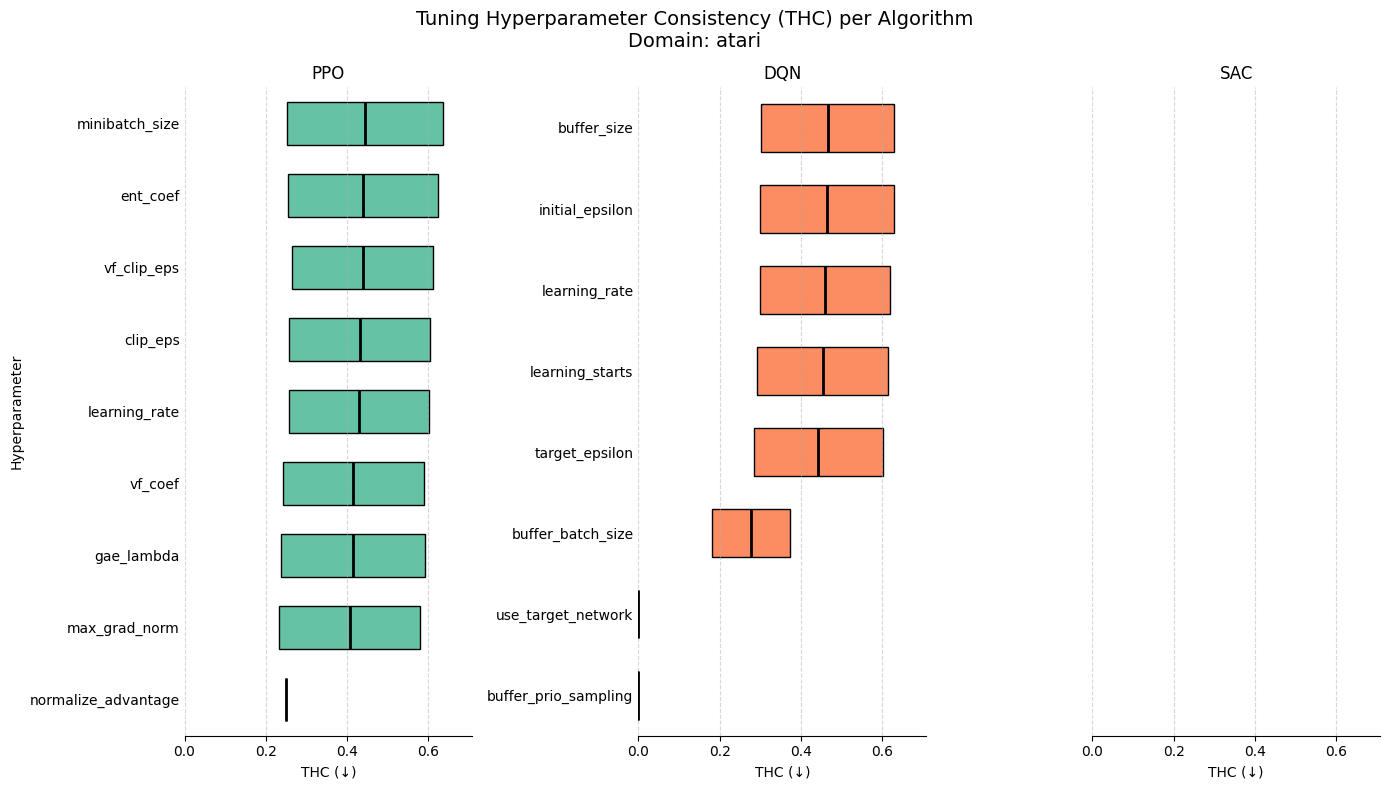

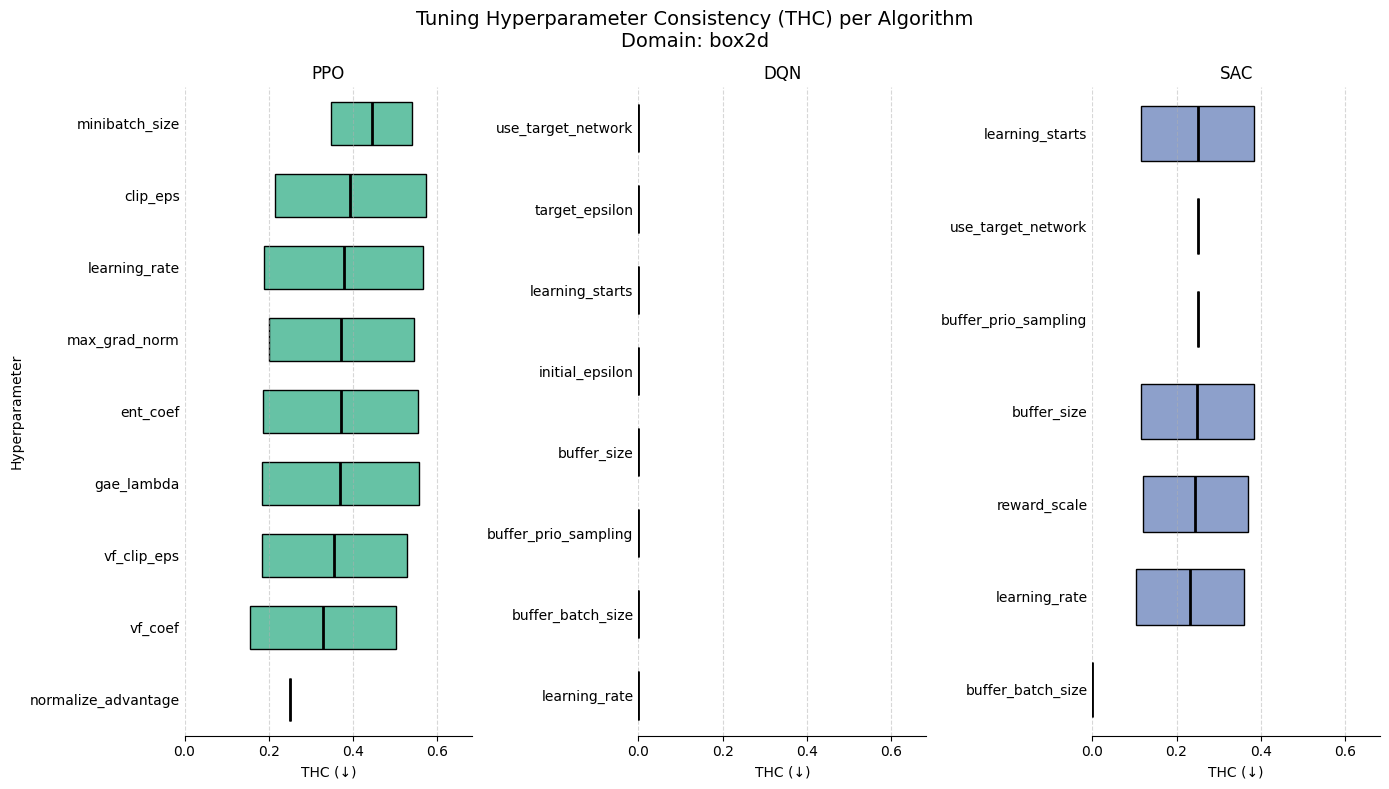

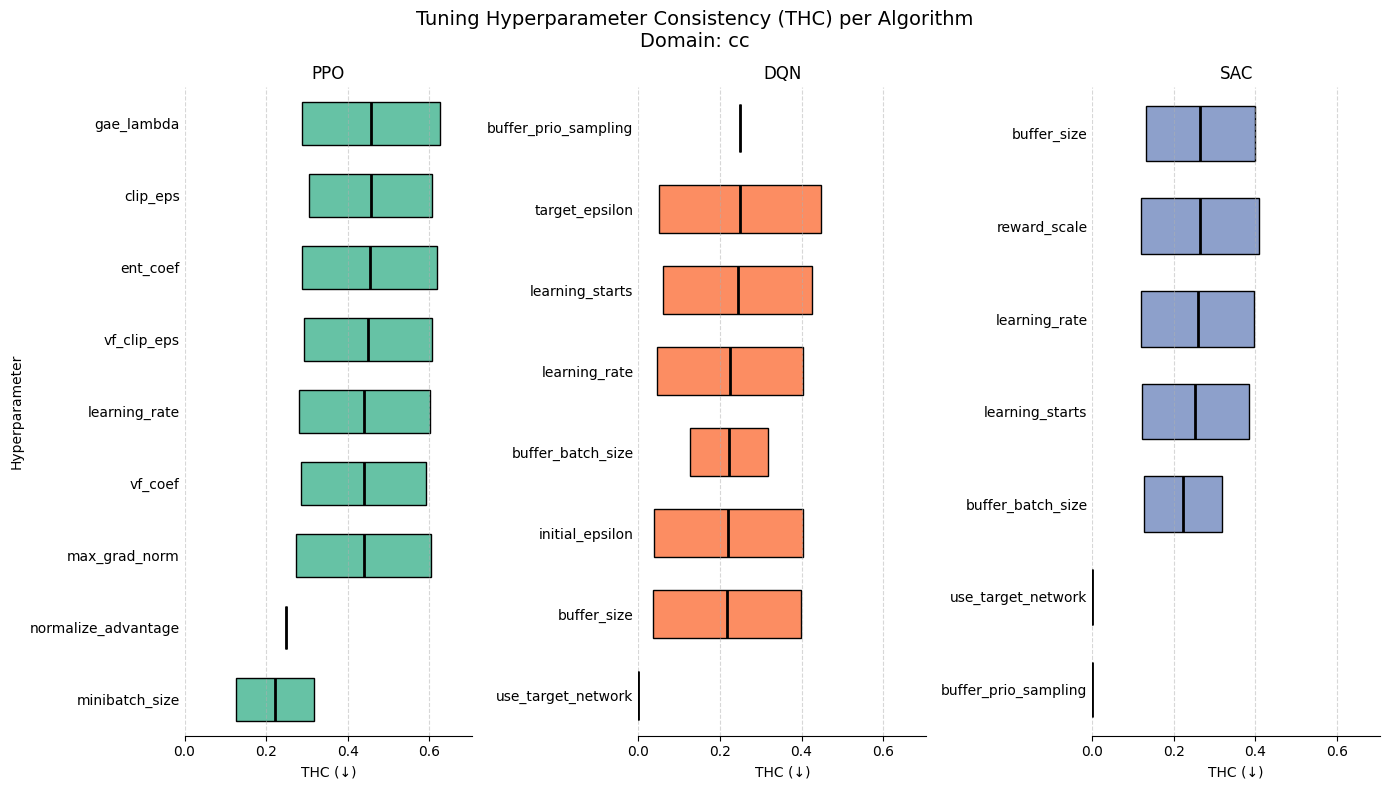

/var/folders/5n/lj6nx7xj3mx2yb3sk947mnlc0000gn/T/ipykernel_84473/108564488.py:46: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(-0.5, len(algo_df) - 0.5)


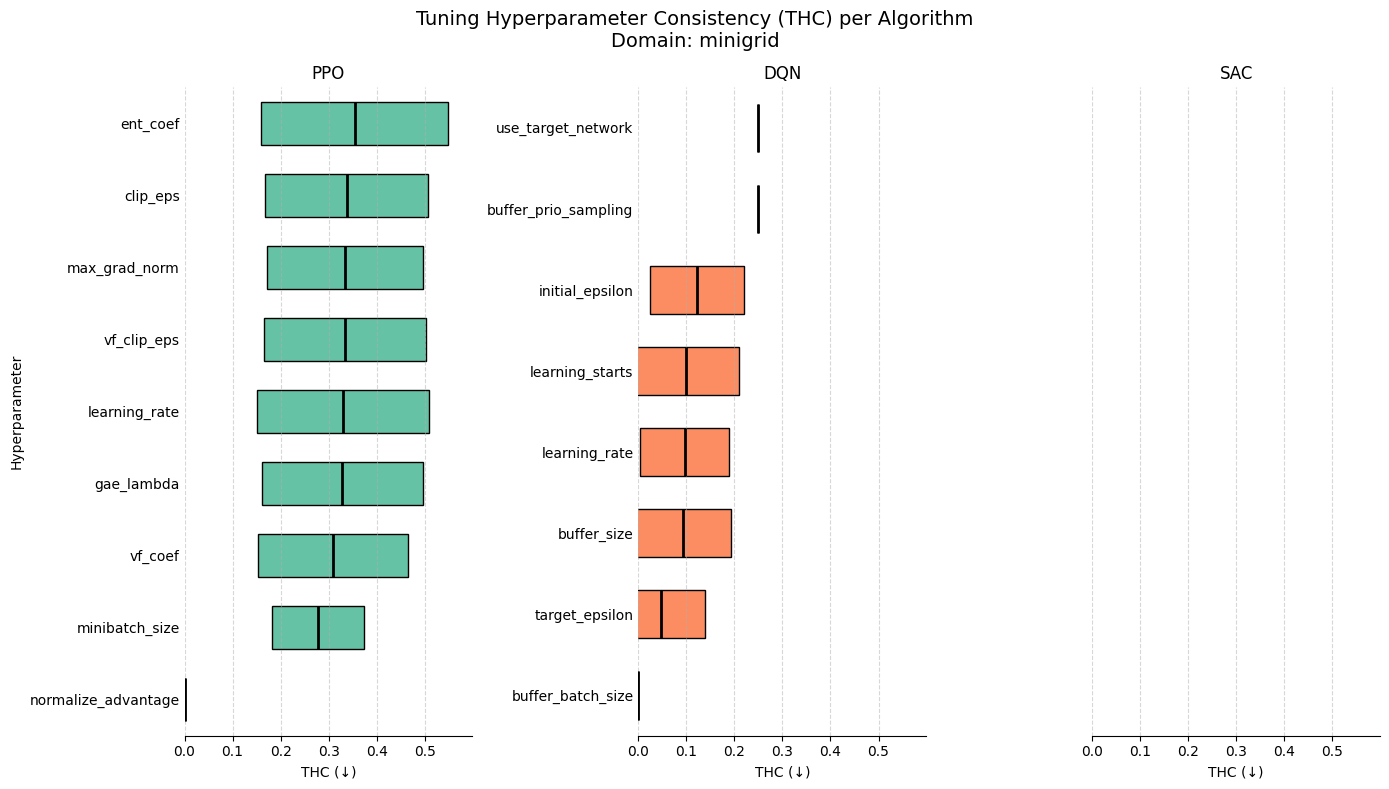

/var/folders/5n/lj6nx7xj3mx2yb3sk947mnlc0000gn/T/ipykernel_84473/108564488.py:46: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(-0.5, len(algo_df) - 0.5)


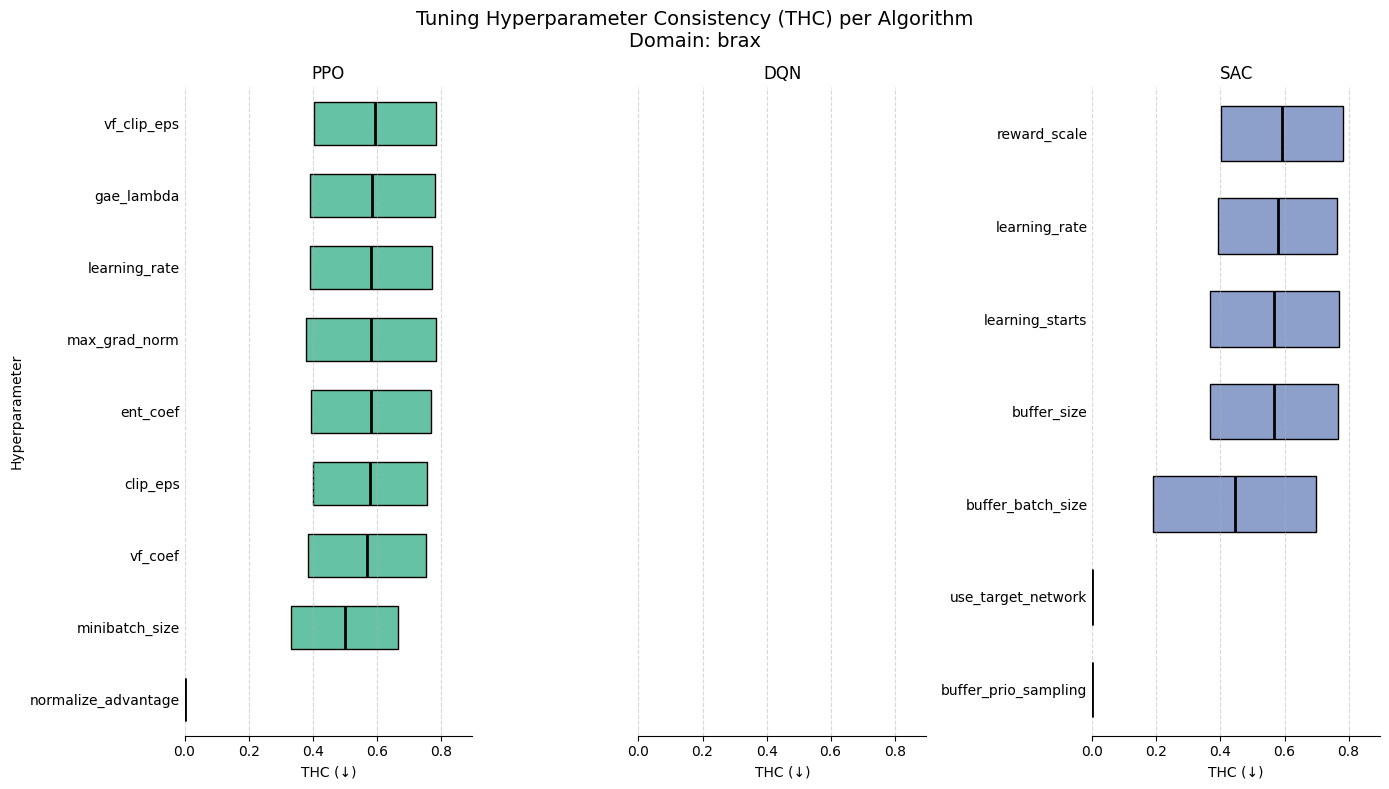

In [13]:
# Plot THC per domain

for domain, thc_summary in thc_summary_per_domain.items():
    # Prepare data for seaborn
    plot_data = []
    for algo in algos:
        for H_i, stats in thc_summary[algo].items():
            if not np.isnan(stats["thc"]):
                plot_data.append({
                    "algorithm": algo.upper(),
                    "hyperparameter": H_i,
                    "thc": stats["thc"],
                    "thc_std": stats["thc_std"]
                })

    plot_df = pd.DataFrame(plot_data)

    fig, axes = plt.subplots(1, 3, figsize=(14, 8))
    palette = sns.color_palette("Set2")

    for idx, algo in enumerate(["PPO", "DQN", "SAC"]):
        ax = axes[idx]
        algo_df = plot_df[plot_df["algorithm"] == algo].sort_values(by="thc", ascending=True).reset_index(drop=True)
        
        for i, (_, row) in enumerate(algo_df.iterrows()):
            # Draw box centered at mean, extending std to left and right
            left = row["thc"] - row["thc_std"]
            height = 0.6

            # Draw the box
            rect = plt.Rectangle(
                (left, i - height/2), 
                row["thc_std"] * 2,  # width = 2 * std
                height,
                facecolor=palette[idx],
                edgecolor="black",
                linewidth=1
            )
            ax.add_patch(rect)
            
            # Draw black line at the mean
            ax.vlines(row["thc"], i - height/2, i + height/2, color="black", linewidth=2)
        
        ax.set_yticks(range(len(algo_df)))
        ax.set_yticklabels(algo_df["hyperparameter"])
        ax.set_ylim(-0.5, len(algo_df) - 0.5)
        ax.set_xlim(0, plot_df["thc"].max() + plot_df["thc_std"].max() + 0.05)
        ax.set_xlabel("THC (↓)")
        ax.set_ylabel("Hyperparameter" if idx == 0 else "")
        ax.set_title(algo)
        
        # Add light grid
        ax.grid(axis='x', linestyle='--', alpha=0.5, zorder=0)
        
        # Remove borders except bottom
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        
        # Remove y-axis ticks (keep labels)
        ax.tick_params(axis='y', length=0)

    plt.suptitle(f"Tuning Hyperparameter Consistency (THC) per Algorithm\nDomain: {domain}", fontsize=14)
    plt.tight_layout()
    plt.show()

/var/folders/5n/lj6nx7xj3mx2yb3sk947mnlc0000gn/T/ipykernel_84473/3780258579.py:21: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'black'}` instead.

  sns.barplot(
/var/folders/5n/lj6nx7xj3mx2yb3sk947mnlc0000gn/T/ipykernel_84473/3780258579.py:21: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(


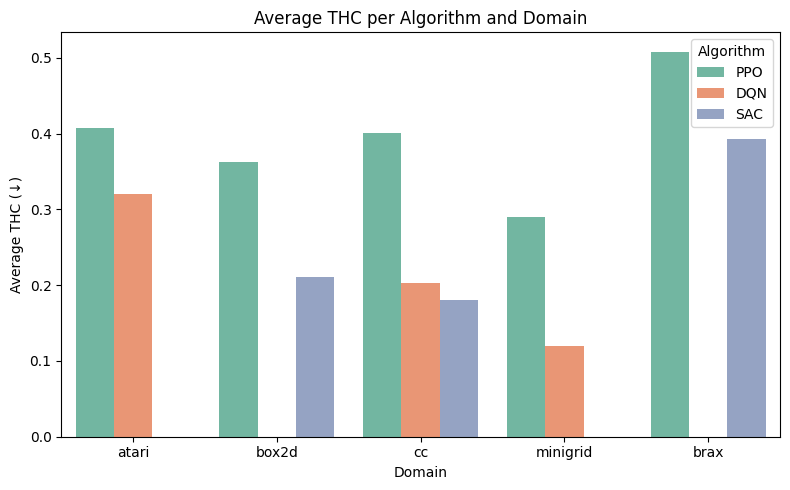

In [19]:
# Plot average THC per algorithm and domain

avg_thc_data = []
for domain, thc_summary in thc_summary_per_domain.items():
    for algo in algos:
        # Collect all THC values for this algorithm in this domain
        thc_vals = [stats["thc"] for stats in thc_summary[algo].values() if not np.isnan(stats["thc"])]
        if thc_vals:
            avg_thc = np.mean(thc_vals)
            std_thc = np.std(thc_vals)
            avg_thc_data.append({
                "domain": domain,
                "algorithm": algo.upper(),
                "avg_thc": avg_thc,
                "std_thc": std_thc
            })

avg_thc_df = pd.DataFrame(avg_thc_data)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=avg_thc_df,
    x="domain",
    y="avg_thc",
    hue="algorithm",
    palette="Set2",
    capsize=0.15,
    errcolor="black",
    errwidth=1
)
plt.ylabel("Average THC (↓)")
plt.xlabel("Domain")
plt.title("Average THC per Algorithm and Domain")
plt.legend(title="Algorithm")
plt.tight_layout()
plt.show()